In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing import image

# For training improvements
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint  # Control training
from tensorflow.keras.layers import BatchNormalization                # Normalize activations

In [2]:
train_dir = "FaceShape Dataset/training_set"
test_dir = "FaceShape Dataset/testing_set"

In [4]:

import os
import random

test_dir = "FaceShape Dataset/testing_set"

round_folder = os.path.join(test_dir, "Round")

images = os.listdir(round_folder)

img = random.choice(images)

os.remove(os.path.join(round_folder, img))

print(f"Deleted: {img}")
print("Round:", len(os.listdir(round_folder)))

Deleted: round (743).jpg
Round: 198


In [5]:

from PIL import Image
import os

bad_images = []

for folder in [train_dir, test_dir]:
    for root, dirs, files in os.walk(folder):
        for file in files:
            if file.lower().endswith((".jpg", ".jpeg", ".png")):
                path = os.path.join(root, file)

                try:
                    img = Image.open(path)
                    img.load()   # Actually loads the whole image
                except Exception:
                    bad_images.append(path)

print("Bad Images Found:", len(bad_images))

for img in bad_images:
    print(img)

Bad Images Found: 0


In [6]:

import os
import random

train_dir = "FaceShape Dataset/training_set"

target_count = 700

for folder in os.listdir(train_dir):

    folder_path = os.path.join(train_dir, folder)

    if os.path.isdir(folder_path):

        images = os.listdir(folder_path)

        if len(images) > target_count:

            # Randomly choose images to delete
            images_to_delete = random.sample(images, len(images) - target_count)

            for img in images_to_delete:
                os.remove(os.path.join(folder_path, img))

            print(f"{folder}: Deleted {len(images_to_delete)} images")

        print(f"{folder}: {len(os.listdir(folder_path))} images remaining")     

Heart: Deleted 50 images
Heart: 700 images remaining
Oblong: Deleted 50 images
Oblong: 700 images remaining
Oval: Deleted 50 images
Oval: 700 images remaining
Round: Deleted 48 images
Round: 700 images remaining
Square: Deleted 50 images
Square: 700 images remaining


In [8]:
train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

train_data = train_gen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode="sparse",
    shuffle=True
)

Found 3500 images belonging to 5 classes.


In [9]:

test_gen = ImageDataGenerator(rescale=1./255)

test_data = test_gen.flow_from_directory(
    test_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode="sparse",
    shuffle=False
)


Found 997 images belonging to 5 classes.


In [10]:
print("Class Labels:", train_data.class_indices)

Class Labels: {'Heart': 0, 'Oblong': 1, 'Oval': 2, 'Round': 3, 'Square': 4}


In [11]:
model = Sequential([

    Conv2D(32,(3,3),activation="relu",input_shape=(224,224,3)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(64,(3,3),activation="relu"),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128,(3,3),activation="relu"),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(256,activation="relu"),
    Dropout(0.5),

    Dense(5,activation="softmax")
])

In [12]:
model.compile(
    optimizer=Adam(learning_rate=0.00001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [13]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)


In [15]:
checkpoint = ModelCheckpoint(
    "best_face_shape.keras",
    monitor="val_accuracy",
    save_best_only=True
)



In [16]:
history = model.fit(
    train_data,
    epochs=20,
    validation_data=test_data,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 173s 2s/step - accuracy: 0.2431 - loss: 2.1347 - val_accuracy: 0.2307 - val_loss: 2.1598
Epoch 2/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 169s 2s/step - accuracy: 0.2794 - loss: 1.6202 - val_accuracy: 0.2357 - val_loss: 2.4498
Epoch 3/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 167s 2s/step - accuracy: 0.3171 - loss: 1.5536 - val_accuracy: 0.2688 - val_loss: 2.3518
Epoch 4/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 171s 1s/step - accuracy: 0.3271 - loss: 1.5222 - val_accuracy: 0.2969 - val_loss: 1.6890
Epoch 5/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 116s 1s/step - accuracy: 0.3483 - loss: 1.5000 - val_accuracy: 0.3661 - val_loss: 1.4993
Epoch 6/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 142s 1s/step - accuracy: 0.3654 - loss: 1.4661 - val_accuracy: 0.3681 - val_loss: 1.4690
Epoch 7/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 119s 1s/step - accuracy: 0.3711 - loss: 1.4805 - val_accuracy: 0.3601 - val_loss: 1.4633
Epoch 8/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 138s 1s/step - accuracy: 0.3794 - loss: 1.4468 - val_accu

Text(0.5, 1.0, 'Accuracy')

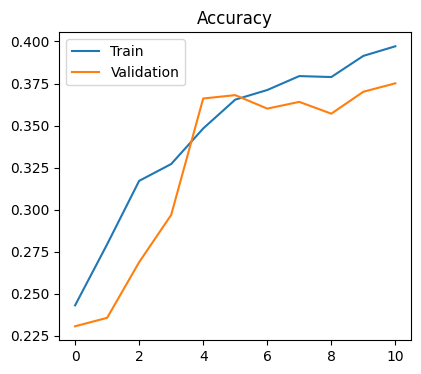

In [17]:
#plotting accuracy
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.legend(['Train','Validation'])

plt.title("Accuracy")

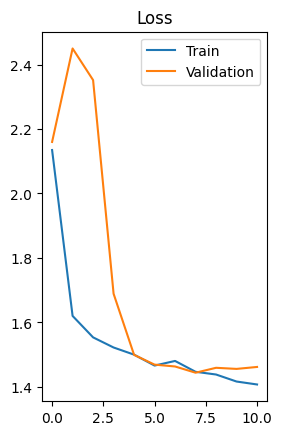

In [18]:
#plotting loss
plt.subplot(1,2,2)

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.legend(['Train','Validation'])

plt.title("Loss")

plt.show()

In [22]:
#testing one image
img_path="test.png"

img = image.load_img(img_path, target_size=(224,224))
img_array=image.img_to_array(img)/255.0


img_array=np.expand_dims(img_array,axis=0)

In [23]:
prediction=model.predict(img_array)
predicted_class=np.argmax(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 313ms/step


In [24]:
class_names=list(train_data.class_indices.keys())
print(class_names[predicted_class])

Round


In [25]:
import os

for folder in os.listdir(train_dir):
    path = os.path.join(train_dir, folder)

    if os.path.isdir(path):
        print(folder, ":", len(os.listdir(path)))

Heart : 700
Oblong : 700
Oval : 700
Round : 700
Square : 700


In [26]:
model.save("face_shape.keras")